# MortgageGuard: Exploratory Analysis and Modeling

## Project objective

MortgageGuard is an early-warning system designed to identify active
mortgages that may become seriously delinquent—90 or more days past
due—within the next six months.

This notebook performs exploratory analysis, creates time-based training,
validation, and test sets, develops baseline and machine-learning models,
and evaluates their usefulness for prioritizing servicing outreach.

The modeling dataset was produced in the data-preparation notebook using
Fannie Mae's 2019 Q1 loan-performance cohort.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

!pip -q install duckdb

from pathlib import Path
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

feature_path = Path(
    "/content/drive/MyDrive/MortgageGuard/"
    "private_data/processed/2019Q1_model_features.parquet"
)

connection = duckdb.connect()

print("Feature file found:", feature_path.exists())
print(f"File size: {feature_path.stat().st_size / (1024**2):.2f} MB")

Mounted at /content/drive
Feature file found: True
File size: 135.77 MB


## 1. Load and verify the modeling dataset

The prepared Parquet file contains active mortgage-month observations,
leakage-safe predictor variables, and the six-month serious-delinquency
target. DuckDB is used to query the full dataset efficiently without loading
all 7.1 million rows into pandas memory.

In [ ]:
connection.execute(f"""
    CREATE OR REPLACE VIEW model_data AS
    SELECT *
    FROM read_parquet('{feature_path}')
""")

dataset_overview = connection.execute("""
    SELECT
        COUNT(*) AS loan_months,
        COUNT(DISTINCT loan_id) AS mortgages,
        COUNT(*) AS rows,
        MIN(reporting_period) AS earliest_date,
        MAX(reporting_period) AS latest_date,
        SUM(serious_delinquency_next_6_months) AS positive_records,
        ROUND(
            100.0 * AVG(serious_delinquency_next_6_months),
            3
        ) AS positive_percentage
    FROM model_data
""").df()

column_count = connection.execute("""
    SELECT COUNT(*)
    FROM (DESCRIBE model_data)
""").fetchone()[0]

display(dataset_overview)
print("Number of columns:", column_count)

,loan_months,mortgages,rows,earliest_date,latest_date,positive_records,positive_percentage
0,7145733,265370,7145733,2019-07-01,2025-09-01,129486.0,1.812


Number of columns: 26


## 2. Target behavior over time

Because mortgage risk changes with economic conditions, the target rate is
examined by observation month. Each point represents the percentage of active
mortgage records that entered serious delinquency within the following six
months.

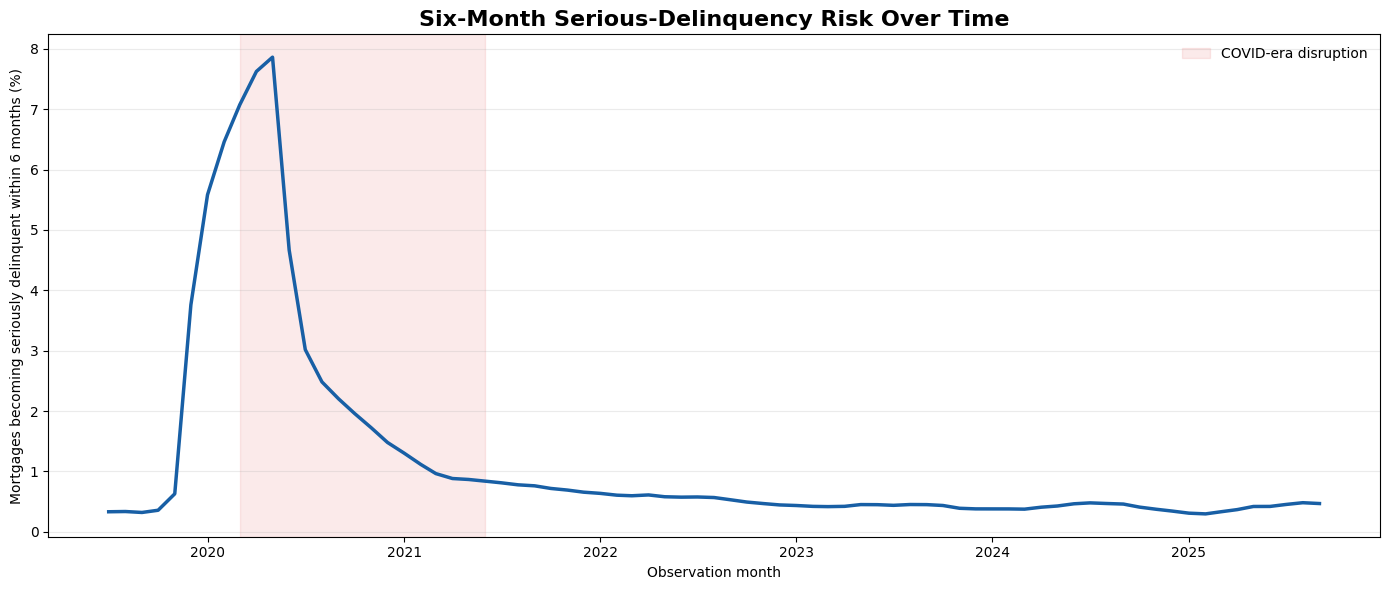

In [ ]:
monthly_risk = connection.execute("""
    SELECT
        reporting_period,
        COUNT(*) AS eligible_records,
        SUM(serious_delinquency_next_6_months) AS positive_records,
        100.0 * AVG(serious_delinquency_next_6_months)
            AS positive_percentage
    FROM model_data
    GROUP BY reporting_period
    ORDER BY reporting_period
""").df()

monthly_risk["reporting_period"] = pd.to_datetime(
    monthly_risk["reporting_period"]
)

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_risk,
    x="reporting_period",
    y="positive_percentage",
    color="#185FA5",
    linewidth=2.5
)

plt.axvspan(
    pd.Timestamp("2020-03-01"),
    pd.Timestamp("2021-06-01"),
    color="#E45756",
    alpha=0.12,
    label="COVID-era disruption"
)

plt.title(
    "Six-Month Serious-Delinquency Risk Over Time",
    fontsize=16,
    weight="bold"
)
plt.xlabel("Observation month")
plt.ylabel("Mortgages becoming seriously delinquent within 6 months (%)")
plt.grid(axis="y", alpha=0.25)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

### Interpretation

The six-month serious-delinquency rate increased sharply as the prediction
windows began overlapping the COVID-19 disruption. The rate rose from 3.76%
in December 2019 to a peak of 7.86% in May 2020, then declined throughout
the remainder of 2020.

The increase begins before March 2020 because the target looks six months
forward. For example, a December 2019 observation is labeled positive if the
mortgage becomes seriously delinquent between January and June 2020.

This pattern demonstrates temporal dataset shift: mortgage risk was not
constant throughout the study period. Therefore, model evaluation should
use chronological splits rather than a random split.

In [ ]:
display(
    monthly_risk.nlargest(
        10,
        "positive_percentage"
    ).reset_index(drop=True)
)

,reporting_period,eligible_records,positive_records,positive_percentage
0,2020-05-01,181096,14240.0,7.863233
1,2020-04-01,190783,14550.0,7.626466
2,2020-03-01,199727,14129.0,7.074156
3,2020-02-01,208601,13477.0,6.460659
4,2020-01-01,218554,12202.0,5.583060
5,2020-06-01,166408,7765.0,4.666242
6,2019-12-01,230318,8657.0,3.758716
7,2020-07-01,154841,4671.0,3.016643
8,2020-08-01,146705,3642.0,2.482533
9,2020-09-01,139039,3061.0,2.201541


In [ ]:
risk_by_current_status = connection.execute("""
    SELECT
        delinquency_status_numeric AS current_status,
        COUNT(*) AS loan_months,
        SUM(serious_delinquency_next_6_months)
            AS positive_records,
        100.0 * AVG(serious_delinquency_next_6_months)
            AS positive_percentage
    FROM model_data
    GROUP BY delinquency_status_numeric
    ORDER BY delinquency_status_numeric
""").df()

risk_by_current_status["status_label"] = (
    risk_by_current_status["current_status"]
    .map({
        0: "Current (00)",
        1: "1 month delinquent (01)",
        2: "2 months delinquent (02)"
    })
)

display(risk_by_current_status)

,current_status,loan_months,positive_records,positive_percentage,status_label
0,0,7011861,74591.0,1.063783,Current (00)
1,1,97951,29026.0,29.633184,1 month delinquent (01)
2,2,35921,25869.0,72.016369,2 months delinquent (02)


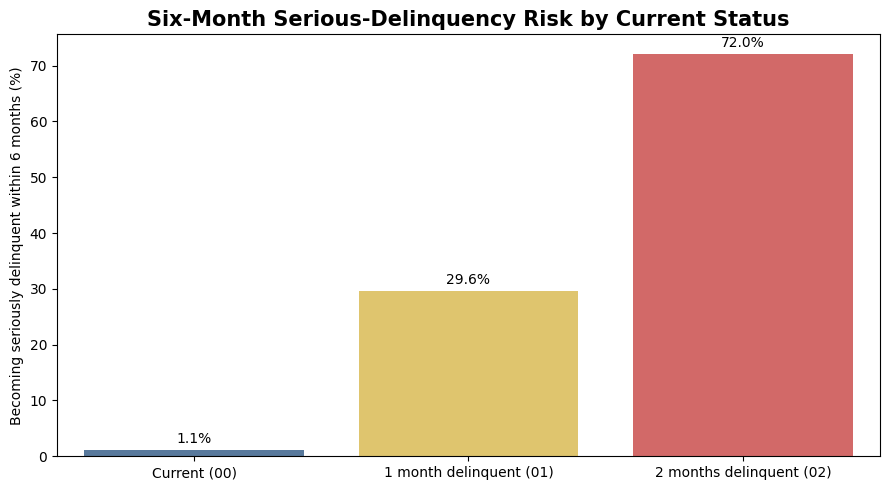

In [ ]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=risk_by_current_status,
    x="status_label",
    y="positive_percentage",
    hue="status_label",
    palette=["#4C78A8", "#F2CF5B", "#E45756"],
    legend=False
)

plt.title(
    "Six-Month Serious-Delinquency Risk by Current Status",
    fontsize=15,
    weight="bold"
)
plt.xlabel("")
plt.ylabel("Becoming seriously delinquent within 6 months (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

### Interpretation

Current payment behavior is a powerful early-warning signal. Only 1.06% of
currently performing observations entered serious delinquency within six
months, compared with 29.63% of observations already one month delinquent
and 72.02% of those two months delinquent.

This supports a tiered servicing strategy. Mortgages at status 02 require
immediate attention, while predictive modeling is especially useful for
finding hidden risk among the much larger status-00 population.

In [ ]:
credit_risk = connection.execute("""
    SELECT
        CASE
            WHEN borrower_credit_score IS NULL THEN 'Missing'
            WHEN borrower_credit_score < 680 THEN 'Below 680'
            WHEN borrower_credit_score < 720 THEN '680–719'
            WHEN borrower_credit_score < 760 THEN '720–759'
            ELSE '760+'
        END AS credit_score_band,

        COUNT(*) AS loan_months,

        100.0 * AVG(serious_delinquency_next_6_months)
            AS positive_percentage

    FROM model_data
    GROUP BY credit_score_band
""").df()

credit_order = [
    "Below 680",
    "680–719",
    "720–759",
    "760+",
    "Missing"
]

credit_risk["credit_score_band"] = pd.Categorical(
    credit_risk["credit_score_band"],
    categories=credit_order,
    ordered=True
)

credit_risk = credit_risk.sort_values("credit_score_band")

display(credit_risk)

,credit_score_band,loan_months,positive_percentage
2,Below 680,897815,3.786192
0,680–719,1454657,2.729647
1,720–759,1817551,1.783499
4,760+,2964609,0.783746
3,Missing,11101,1.216107


In [ ]:
ltv_risk = connection.execute("""
    SELECT
        CASE
            WHEN original_ltv IS NULL THEN 'Missing'
            WHEN original_ltv <= 60 THEN '60 or below'
            WHEN original_ltv <= 80 THEN '61–80'
            WHEN original_ltv <= 90 THEN '81–90'
            ELSE 'Above 90'
        END AS ltv_band,

        COUNT(*) AS loan_months,

        100.0 * AVG(serious_delinquency_next_6_months)
            AS positive_percentage

    FROM model_data
    GROUP BY ltv_band
""").df()

ltv_order = [
    "60 or below",
    "61–80",
    "81–90",
    "Above 90",
    "Missing"
]

ltv_risk["ltv_band"] = pd.Categorical(
    ltv_risk["ltv_band"],
    categories=ltv_order,
    ordered=True
)

ltv_risk = ltv_risk.sort_values("ltv_band")

display(ltv_risk)

,ltv_band,loan_months,positive_percentage
1,60 or below,1424785,1.013206
0,61–80,3079139,1.660204
3,81–90,752313,2.005415
2,Above 90,1889496,2.584975


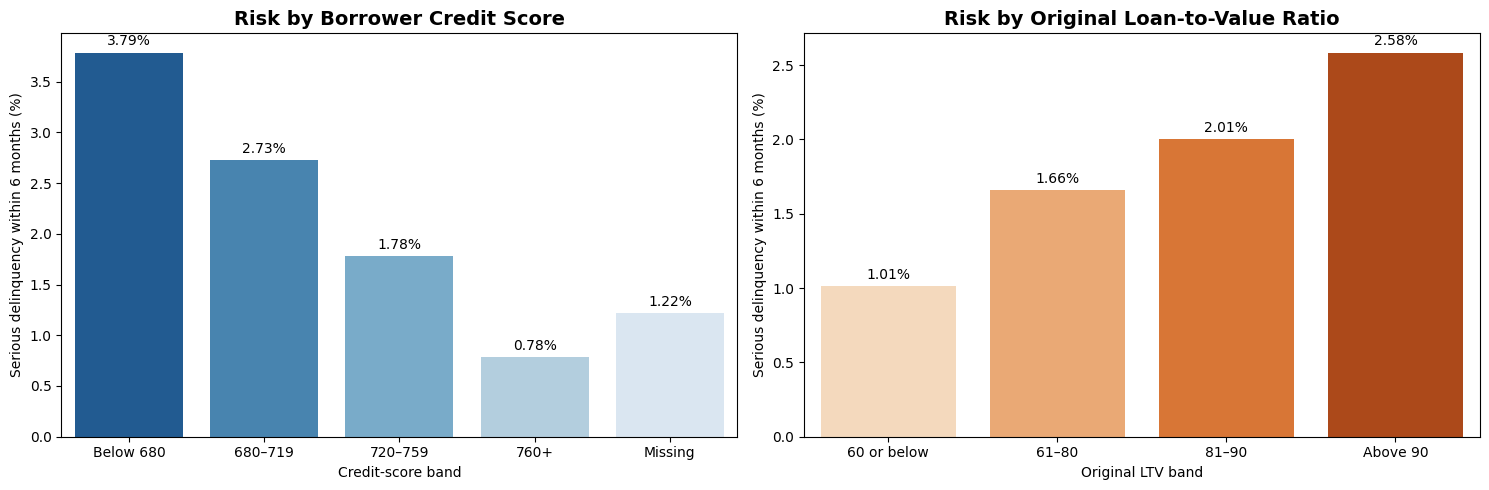

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Credit-score chart
sns.barplot(
    data=credit_risk,
    x="credit_score_band",
    y="positive_percentage",
    hue="credit_score_band",
    palette="Blues_r",
    legend=False,
    ax=axes[0]
)

axes[0].set_title(
    "Risk by Borrower Credit Score",
    fontsize=14,
    weight="bold"
)
axes[0].set_xlabel("Credit-score band")
axes[0].set_ylabel("Serious delinquency within 6 months (%)")

for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.2f%%", padding=3)

ltv_risk["ltv_band"] = (
    ltv_risk["ltv_band"]
    .cat.remove_unused_categories()
)
# LTV chart
sns.barplot(
    data=ltv_risk,
    x="ltv_band",
    y="positive_percentage",
    hue="ltv_band",
    palette="Oranges",
    legend=False,
    ax=axes[1]
)

axes[1].set_title(
    "Risk by Original Loan-to-Value Ratio",
    fontsize=14,
    weight="bold"
)
axes[1].set_xlabel("Original LTV band")
axes[1].set_ylabel("Serious delinquency within 6 months (%)")

for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f%%", padding=3)

plt.tight_layout()
plt.show()

### Interpretation

Borrower and loan characteristics show consistent risk gradients. The
six-month serious-delinquency rate falls from 3.79% among observations with
credit scores below 680 to 0.78% among those with scores of 760 or higher.

Risk also increases with original loan-to-value ratio, rising from 1.01%
for LTV values of 60 or below to 2.58% for LTV values above 90. Higher LTV
generally indicates a smaller initial equity cushion.

These relationships support including credit score and LTV in the model,
but they should inform outreach prioritization rather than be used as
standalone decision rules.

## 3. Chronological train, validation, and test split

The data is split chronologically to simulate production use, where a model
is trained on historical observations and evaluated on future periods.

Six-month embargo periods are placed between the datasets because each
target uses the following six months. This prevents overlapping outcome
windows from leaking information across the split boundaries.

- Training: July 2019–December 2022
- Embargo: January–June 2023
- Validation: July–December 2023
- Embargo: January–June 2024
- Test: July 2024–September 2025

In [ ]:
split_summary = connection.execute("""
    WITH assigned_splits AS (
        SELECT
            CASE
                WHEN reporting_period BETWEEN
                     DATE '2019-07-01' AND DATE '2022-12-01'
                    THEN 'Training'

                WHEN reporting_period BETWEEN
                     DATE '2023-07-01' AND DATE '2023-12-01'
                    THEN 'Validation'

                WHEN reporting_period BETWEEN
                     DATE '2024-07-01' AND DATE '2025-09-01'
                    THEN 'Test'

                ELSE 'Embargo'
            END AS dataset_split,

            loan_id,
            serious_delinquency_next_6_months AS target

        FROM model_data
    )

    SELECT
        dataset_split,
        COUNT(*) AS loan_months,
        COUNT(DISTINCT loan_id) AS mortgages,
        SUM(target) AS positive_records,
        ROUND(100.0 * AVG(target), 3) AS positive_percentage

    FROM assigned_splits
    GROUP BY dataset_split

    ORDER BY CASE dataset_split
        WHEN 'Training' THEN 1
        WHEN 'Validation' THEN 2
        WHEN 'Test' THEN 3
        ELSE 4
    END
""").df()

display(split_summary)

,dataset_split,loan_months,mortgages,positive_records,positive_percentage
0,Training,5171659,265370,121333.0,2.346
1,Validation,378072,64059,1600.0,0.423
2,Test,839997,58808,3393.0,0.404
3,Embargo,756005,67016,3160.0,0.418


## 4. Operational baseline

Before training machine-learning models, a simple rule-based benchmark is
evaluated on the validation period. The rule flags mortgages whose current
delinquency status is 01 or 02.

This establishes whether a machine-learning model provides value beyond
information that a servicing team already has.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

validation_baseline = connection.execute("""
    SELECT
        delinquency_status_numeric AS risk_score,
        serious_delinquency_next_6_months AS target
    FROM model_data
    WHERE reporting_period BETWEEN
          DATE '2023-07-01' AND DATE '2023-12-01'
""").df()

y_val = validation_baseline["target"].astype(int)
baseline_score = validation_baseline["risk_score"]
baseline_prediction = (baseline_score >= 1).astype(int)

baseline_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Validation result": [
        accuracy_score(y_val, baseline_prediction),
        precision_score(y_val, baseline_prediction),
        recall_score(y_val, baseline_prediction),
        f1_score(y_val, baseline_prediction),
        roc_auc_score(y_val, baseline_score),
        average_precision_score(y_val, baseline_score)
    ]
})

baseline_results["Validation result"] = (
    baseline_results["Validation result"].round(4)
)

display(baseline_results)

,Metric,Validation result
0,Accuracy,0.9853
1,Precision,0.1642
2,Recall,0.6056
3,F1 score,0.2584
4,ROC-AUC,0.7977
5,PR-AUC,0.1907


In [ ]:
tn, fp, fn, tp = confusion_matrix(
    y_val,
    baseline_prediction
).ravel()

baseline_confusion = pd.DataFrame({
    "Outcome": [
        "True negatives",
        "False positives",
        "False negatives",
        "True positives"
    ],
    "Count": [tn, fp, fn, tp]
})

display(baseline_confusion)

,Outcome,Count
0,True negatives,371541
1,False positives,4931
2,False negatives,631
3,True positives,969


In [ ]:
!pip -q install lightgbm

import lightgbm as lgb

target_column = "serious_delinquency_next_6_months"

numeric_features = [
    "current_interest_rate",
    "current_actual_upb",
    "loan_age",
    "delinquency_status_numeric",
    "original_interest_rate",
    "original_upb",
    "original_loan_term",
    "original_ltv",
    "original_cltv",
    "debt_to_income_ratio",
    "borrower_credit_score",
    "number_of_units",
    "interest_rate_change",
    "current_to_original_balance_ratio",
    "principal_reduction_ratio",
    "delinquency_status_1_month_ago",
    "delinquency_status_2_months_ago",
    "delinquent_months_last_3"
]

categorical_features = [
    "channel",
    "loan_purpose",
    "property_type",
    "occupancy_status",
    "property_state"
]

model_features = numeric_features + categorical_features
feature_sql = ", ".join(model_features)

In [ ]:
train_data = connection.execute(f"""
    SELECT
        {feature_sql},
        {target_column}
    FROM model_data
    WHERE reporting_period BETWEEN
          DATE '2019-07-01' AND DATE '2022-12-01'

      AND (
          {target_column} = 1
          OR hash(loan_id, reporting_period) % 5 = 0
      )
""").df()

validation_data = connection.execute(f"""
    SELECT
        {feature_sql},
        {target_column}
    FROM model_data
    WHERE reporting_period BETWEEN
          DATE '2023-07-01' AND DATE '2023-12-01'
""").df()

print("Training sample shape:", train_data.shape)
print("Validation shape:", validation_data.shape)

print(
    "Training positive rate:",
    round(100 * train_data[target_column].mean(), 3),
    "%"
)

print(
    "Validation positive rate:",
    round(100 * validation_data[target_column].mean(), 3),
    "%"
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Training sample shape: (1131804, 24)
Validation shape: (378072, 24)
Training positive rate: 10.72 %
Validation positive rate: 0.423 %


In [ ]:
# Make categorical levels identical in training and validation
for column in categorical_features:
    categories = sorted(
        set(train_data[column].dropna().astype(str))
        | set(validation_data[column].dropna().astype(str))
    )

    train_data[column] = pd.Categorical(
        train_data[column].astype(str),
        categories=categories
    )

    validation_data[column] = pd.Categorical(
        validation_data[column].astype(str),
        categories=categories
    )

X_train = train_data[model_features]
y_train = train_data[target_column].astype(int)

X_val = validation_data[model_features]
y_val = validation_data[target_column].astype(int)

# Correct for the 20% negative sampling rate
training_weights = np.where(y_train == 0, 5.0, 1.0)

In [ ]:
lgbm_model = lgb.LGBMClassifier(
    objective="binary",
    metric="average_precision",
    n_estimators=1500,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=100,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    force_col_wise=True
)

lgbm_model.fit(
    X_train,
    y_train,
    sample_weight=training_weights,

    eval_set=[(X_val, y_val)],
    eval_metric="average_precision",

    categorical_feature=categorical_features,

    callbacks=[
        lgb.early_stopping(
            stopping_rounds=50,
            first_metric_only=True,
            verbose=True
        ),
        lgb.log_evaluation(period=50)
    ]
)

print("PR-AUC optimized best iteration:", lgbm_model.best_iteration_)
print(
    "Best validation PR-AUC:",
    round(
        lgbm_model.best_score_["valid_0"]["average_precision"],
        4
    )
)

[LightGBM] [Info] Number of positive: 121333, number of negative: 1010471
[LightGBM] [Info] Total Bins 1918
[LightGBM] [Info] Number of data points in the train set: 1131804, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.023452 -> initscore=-3.729071
[LightGBM] [Info] Start training from score -3.729071
Training until validation scores don't improve for 50 rounds
[50]	valid_0's average_precision: 0.249973
[100]	valid_0's average_precision: 0.256135
[150]	valid_0's average_precision: 0.261675
[200]	valid_0's average_precision: 0.263064
Early stopping, best iteration is:
[176]	valid_0's average_precision: 0.26332
Evaluated only: average_precision
PR-AUC optimized best iteration: 176
Best validation PR-AUC: 0.2633


In [ ]:
validation_probabilities = lgbm_model.predict_proba(X_val)[:, 1]

baseline_alert_count = int(baseline_prediction.sum())

# Select exactly the highest-risk records
highest_risk_indices = np.argsort(
    -validation_probabilities
)[:baseline_alert_count]

model_prediction_same_capacity = np.zeros(
    len(y_val),
    dtype=int
)

model_prediction_same_capacity[
    highest_risk_indices
] = 1

print("Baseline alerts:", baseline_alert_count)
print(
    "Model alerts:",
    model_prediction_same_capacity.sum()
)

Baseline alerts: 5900
Model alerts: 5900


In [ ]:
def capacity_metrics(y_true, predictions, scores):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions
    ).ravel()

    return {
        "Alerts": int(predictions.sum()),
        "True positives": int(tp),
        "False positives": int(fp),
        "False negatives": int(fn),
        "Precision": precision_score(y_true, predictions),
        "Recall": recall_score(y_true, predictions),
        "F1 score": f1_score(y_true, predictions),
        "ROC-AUC": roc_auc_score(y_true, scores),
        "PR-AUC": average_precision_score(y_true, scores)
    }

comparison = pd.DataFrame({
    "Operational baseline": capacity_metrics(
        y_val,
        baseline_prediction,
        baseline_score
    ),
    "LightGBM": capacity_metrics(
        y_val,
        model_prediction_same_capacity,
        validation_probabilities
    )
}).T

display(
    comparison.style.format({
        "Alerts": "{:,.0f}",
        "True positives": "{:,.0f}",
        "False positives": "{:,.0f}",
        "False negatives": "{:,.0f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1 score": "{:.3f}",
        "ROC-AUC": "{:.3f}",
        "PR-AUC": "{:.3f}"
    })
)

,Alerts,True positives,False positives,False negatives,Precision,Recall,F1 score,ROC-AUC,PR-AUC
Operational baseline,"5,900",969,"4,931",631,0.164,0.606,0.258,0.798,0.191
LightGBM,"5,900",972,"4,928",628,0.165,0.608,0.259,0.894,0.263


### Baseline comparison

At the same capacity of 5,900 alerts, LightGBM identified 972 future serious
delinquencies compared with 969 for the operational rule. This is only a
small improvement because current delinquency status is already a powerful
late-stage warning signal.

However, the machine-learning model has substantially stronger overall
ranking performance, with validation PR-AUC increasing from 0.191 to 0.263.
Its primary incremental value should therefore be evaluated among mortgages
that are still current, where the operational rule provides no ranking.

In [ ]:
current_mask = (
    X_val["delinquency_status_numeric"] == 0
)

current_y = y_val[current_mask].reset_index(drop=True)
current_probabilities = validation_probabilities[current_mask]

current_results = []

for capacity_percentage in [1, 2, 5, 10]:
    alert_count = int(
        len(current_y) * capacity_percentage / 100
    )

    selected_indices = np.argsort(
        -current_probabilities
    )[:alert_count]

    predictions = np.zeros(
        len(current_y),
        dtype=int
    )
    predictions[selected_indices] = 1

    true_positives = int(
        ((predictions == 1) & (current_y == 1)).sum()
    )

    precision = precision_score(
        current_y,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        current_y,
        predictions,
        zero_division=0
    )

    base_rate = current_y.mean()
    lift = precision / base_rate

    current_results.append({
        "Outreach capacity": f"Top {capacity_percentage}%",
        "Alerts": alert_count,
        "True positives": true_positives,
        "Precision": precision,
        "Recall": recall,
        "Lift vs random": lift
    })

current_loan_results = pd.DataFrame(current_results)

display(
    current_loan_results.style.format({
        "Alerts": "{:,.0f}",
        "True positives": "{:,.0f}",
        "Precision": "{:.3%}",
        "Recall": "{:.3%}",
        "Lift vs random": "{:.1f}×"
    })
)

print("Current-loan observations:", f"{len(current_y):,}")
print("Future serious delinquencies:", f"{current_y.sum():,}")
print("Current-loan base rate:", f"{100 * current_y.mean():.3f}%")

,Outreach capacity,Alerts,True positives,Precision,Recall,Lift vs random
0,Top 1%,"3,721",100,2.687%,15.848%,15.9×
1,Top 2%,"7,443",119,1.599%,18.859%,9.4×
2,Top 5%,"18,608",159,0.854%,25.198%,5.0×
3,Top 10%,"37,217",218,0.586%,34.548%,3.5×


Current-loan observations: 372,172
Future serious delinquencies: 631
Current-loan base rate: 0.170%


### Early warning among currently performing mortgages

Among currently performing mortgages, only 0.17% entered serious
delinquency within six months. MortgageGuard concentrated 15.85% of these
future events within the highest-risk 1% of observations.

The resulting precision of 2.69% represents 15.9 times the event rate of
random outreach. This demonstrates the model's primary value: identifying
hidden risk before the borrower has already missed a payment.

The selected operating policy is to prioritize the top 1% of currently
performing mortgages for proactive outreach, while existing delinquency
rules continue handling loans already at status 01 or 02.

In [ ]:
import gc

category_levels = {
    column: X_val[column].cat.categories
    for column in categorical_features
}

del train_data
del X_train
del training_weights

gc.collect()

print("Training memory released.")

Training memory released.


In [ ]:
test_data = connection.execute(f"""
    SELECT
        {feature_sql},
        {target_column}
    FROM model_data
    WHERE reporting_period BETWEEN
          DATE '2024-07-01' AND DATE '2025-09-01'
""").df()

for column in categorical_features:
    test_data[column] = pd.Categorical(
        test_data[column].astype(str),
        categories=category_levels[column]
    )

X_test = test_data[model_features]
y_test = test_data[target_column].astype(int)

print("Test shape:", test_data.shape)
print(
    "Test positive rate:",
    f"{100 * y_test.mean():.3f}%"
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Test shape: (839997, 24)
Test positive rate: 0.404%


In [ ]:
test_probabilities = lgbm_model.predict_proba(
    X_test
)[:, 1]

test_roc_auc = roc_auc_score(
    y_test,
    test_probabilities
)

test_pr_auc = average_precision_score(
    y_test,
    test_probabilities
)

print("Final test ROC-AUC:", round(test_roc_auc, 4))
print("Final test PR-AUC:", round(test_pr_auc, 4))

Final test ROC-AUC: 0.8846
Final test PR-AUC: 0.2399


In [ ]:
test_current_mask = (
    X_test["delinquency_status_numeric"] == 0
)

test_current_y = (
    y_test[test_current_mask]
    .reset_index(drop=True)
)

test_current_probabilities = (
    test_probabilities[test_current_mask]
)

test_current_alert_count = int(
    len(test_current_y) * 0.01
)

test_current_selected = np.argsort(
    -test_current_probabilities
)[:test_current_alert_count]

test_current_predictions = np.zeros(
    len(test_current_y),
    dtype=int
)

test_current_predictions[
    test_current_selected
] = 1

current_test_tp = int(
    (
        (test_current_predictions == 1)
        & (test_current_y == 1)
    ).sum()
)

current_test_precision = precision_score(
    test_current_y,
    test_current_predictions
)

current_test_recall = recall_score(
    test_current_y,
    test_current_predictions
)

current_test_base_rate = test_current_y.mean()

current_test_lift = (
    current_test_precision / current_test_base_rate
)

current_test_results = pd.DataFrame({
    "Metric": [
        "Current-loan observations",
        "Future serious delinquencies",
        "Top-1% alerts",
        "True positives captured",
        "Precision",
        "Recall",
        "Base rate",
        "Lift versus random"
    ],
    "Test result": [
        len(test_current_y),
        int(test_current_y.sum()),
        test_current_alert_count,
        current_test_tp,
        current_test_precision,
        current_test_recall,
        current_test_base_rate,
        current_test_lift
    ]
})

display(current_test_results)

,Metric,Test result
0,Current-loan observations,827402.000000
1,Future serious delinquencies,1416.000000
2,Top-1% alerts,8274.000000
3,True positives captured,258.000000
4,Precision,0.031182
5,Recall,0.182203
6,Base rate,0.001711
7,Lift versus random,18.220383


### Final out-of-time test results

The final model achieved a ROC-AUC of 0.8846 and a PR-AUC of 0.2399 on
the untouched July 2024–September 2025 test period.

Among mortgages that were still current, only 0.171% became seriously
delinquent within six months. MortgageGuard's highest-risk 1% captured
258 of 1,416 future events, corresponding to 18.22% recall, 3.12%
precision, and 18.22 times the yield of random outreach.

The test performance closely matched or exceeded validation performance,
indicating that the selected operating policy generalized to a later
time period.

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": model_features,
    "Importance": lgbm_model.booster_.feature_importance(
        importance_type="gain"
    )
})

feature_importance["Importance percentage"] = (
    100
    * feature_importance["Importance"]
    / feature_importance["Importance"].sum()
)

feature_importance = feature_importance.sort_values(
    "Importance percentage",
    ascending=False
).reset_index(drop=True)

display(feature_importance.head(15))

,Feature,Importance,Importance percentage
0,delinquency_status_numeric,1.863671e+06,40.501662
1,delinquent_months_last_3,1.053366e+06,22.891951
2,loan_age,5.700632e+05,12.388722
3,principal_reduction_ratio,2.714608e+05,5.899438
4,borrower_credit_score,2.047386e+05,4.449418
5,current_to_original_balance_ratio,1.958301e+05,4.255818
6,property_state,1.308009e+05,2.842590
7,debt_to_income_ratio,8.433745e+04,1.832838
8,current_actual_upb,5.405709e+04,1.174779
9,original_upb,4.300992e+04,0.934700


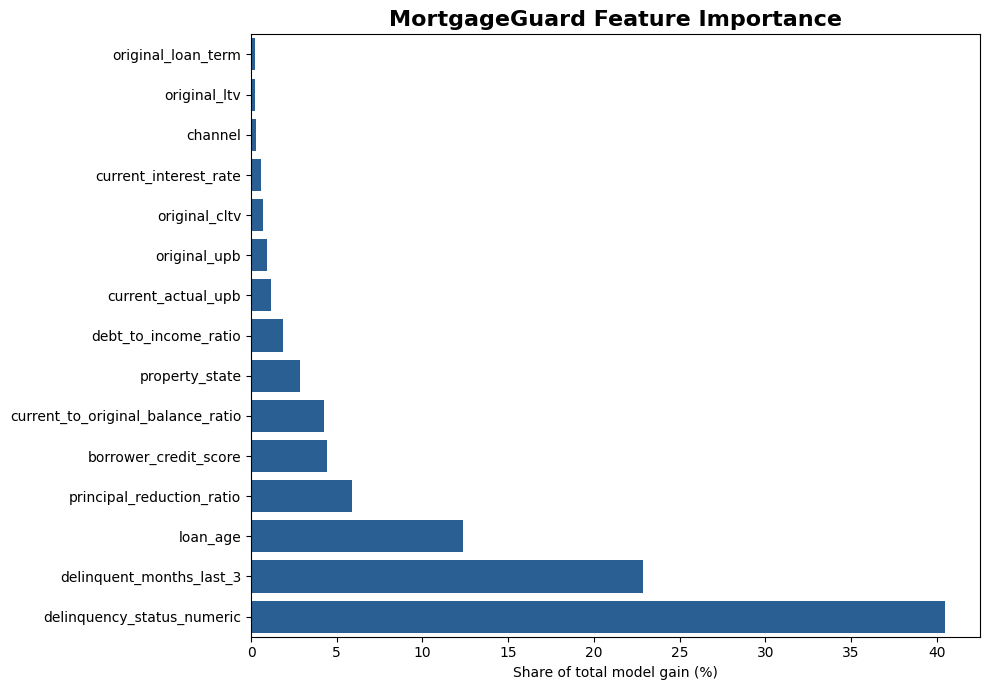

In [ ]:
top_features = (
    feature_importance
    .head(15)
    .sort_values("Importance percentage")
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance percentage",
    y="Feature",
    color="#185FA5"
)

plt.title(
    "MortgageGuard Feature Importance",
    fontsize=16,
    weight="bold"
)
plt.xlabel("Share of total model gain (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 5. Limitations, fairness, and responsible use

MortgageGuard is designed to prioritize supportive mortgage-servicing
outreach. It should not be used to approve or deny mortgages, determine
interest rates, initiate foreclosure, or make other adverse decisions.

### Limitations

- The analysis uses mortgages acquired during 2019 Q1, so results may not
  generalize to every origination period or mortgage product.
- The training period includes the COVID-19 disruption, which caused a
  substantial change in delinquency behavior.
- Loan-month observations from the same mortgage are correlated and should
  not be interpreted as independent borrowers.
- The target identifies serious delinquency within six months but does not
  distinguish between temporary hardship, servicing errors, natural
  disasters, or persistent inability to pay.
- Performance may change as economic conditions, interest rates, servicing
  practices, and borrower-assistance programs change.

### Fairness considerations

Property state contributed to the model and may capture regional economic
conditions, but geography can also act as a proxy for demographic and
socioeconomic characteristics. Before operational use, performance should
be audited across geographic and legally appropriate borrower groups.

Risk scores should be used to offer assistance consistently, such as early
communication, payment counseling, or information about hardship programs.
Human review, appeal mechanisms, data-quality monitoring, and regular model
revalidation would be required in a real deployment.

### Data and reproducibility

The raw Fannie Mae loan-performance files are not included in the public
repository. Users must obtain the data directly from Fannie Mae and comply
with its applicable terms. The repository documents the processing steps,
feature definitions, temporal split, and model configuration needed to
reproduce the analysis.

## Conclusion

MortgageGuard achieved **0.8846 ROC-AUC** and **0.2399 PR-AUC** on the
untouched July 2024–September 2025 test period. Among mortgages that were
still current, the highest-risk 1% captured **258 of 1,416** future serious
delinquencies, producing **18.22% recall**, **3.12% precision**, and
**18.22x lift** over random outreach.

The model's appropriate use is prioritizing supportive early outreach. It is
not intended for credit approval, pricing, foreclosure, or other adverse
decisions.
